In [1]:
from dataclasses import dataclass, field, InitVar
from math import tau, cos, sin
import numpy as np
import hashlib
from collections.abc import Iterable, Generator, Iterator
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FixedLocator

In [2]:
def to_decibel(p: np.ndarray, p_0: np.ndarray) -> np.ndarray:
    return 10.0 * np.log10((p + 1e-10) / (p_0 + 1e-10))


def _filter_pass(state: tuple[float, float], sample: float, omega: complex) -> tuple[float, float]:
    d1, d2 = state
    y = sample + omega.real * d1 - d2
    return y, d1


def _power(state: tuple[float, float], omega: complex) -> float:
    d1, d2 = state
    return pow(d1, 2) + pow(d2, 2) - omega.real * d1 * d2


@dataclass(slots=True, frozen=True)
class State:
    """
    Represents a copy of the Goertzel filter state at a specific point in time `n`.
    """
    
    omega: complex
    state: tuple[float, float]

    @property
    def d1(self) -> float:
        """
        Return the value of the intermediate sequence at time `n`.
        """
        return self.state[0]

    @property
    def d2(self) -> float:
        """
        Return the value of the intermediate sequence at time `n - 1`.
        """
        return self.state[1]

    def power(self) -> float:
        """
        Return the spectral power (absolute value, linear scale)
        """
        return _power(self.state, self.omega)


@dataclass(slots=True)
class Goertzel:
    """
    Implements the Goertzel algorithm for an unknown number of samples. This is to be used when streaming data.
    """
    
    sample_rate: InitVar[int]
    frequency: InitVar[int]
    omega: complex = field(init=False)
    state: tuple[float, float] = field(init=False, default=(0.0, 0.0))

    def __post_init__(self, sample_rate: int, frequency: int) -> None:
        phi = tau * frequency / sample_rate
        self.omega = complex(2 * cos(phi), sin(phi))

    def reset(self) -> None:
        """
        Reset the state of the filter and thus discard all previously integrated data.
        """
        self.state = (0.0, 0.0)

    def add_sample(self, sample: float) -> State:
        """
        Add a single sample of a discrete waveform and return a frozen copy of the current filter state.
        """
        self.state = _filter_pass(self.state, sample, self.omega)
        return State(self.omega, self.state)


@dataclass(slots=True)
class Oscillator:
    """
    Represents a circular iterator over the range 0:period_length. This iterator is infinite.
    """
    
    period_length: int
    counter: int = field(init=False, default=0)

    def reset(self) -> None:
        """
        Reset the current iteration count to zero.
        """
        self.counter = 0

    def __iter__(self) -> 'Oscillator':
        return self

    def __next__(self) -> int:
        self.counter = (self.counter + 1) % self.period_length
        return self.counter


@dataclass
class TwoToneGoertzel:
    """
    Given a 2-FSK encoded source signal, apply to it two separate Goertzel filters, and return their states at specific time points with continuous clock synchronization.
    This class implements the Iterable interface, so it works even for unbounded signals.
    An internal oscillator represents the bit clock which resets the Goertzel filters periodically to allow bit signal retrieval.
    """
    
    source: InitVar[Iterable[float]]
    sample_rate: InitVar[int]
    mark_frequency: InitVar[int]
    space_frequency: InitVar[int]
    bit_width: InitVar[int]
    edge_threshold: float = field(default=0.5)
    sync_tolerance: int = field(default=3)
    edge_state: bool = field(init=False, default=False)
    prev_power_delta: float = field(init=False, default=0.0)
    mark: Goertzel = field(init=False)
    space: Goertzel = field(init=False)
    nco: Oscillator = field(init=False)
    source_iter: Iterator[tuple[int, float]] = field(init=False)

    def __post_init__(self, source: Iterable[float], sample_rate: int, mark_frequency: int, space_frequency: int, bit_width: int) -> None:
        self.mark = Goertzel(sample_rate, mark_frequency)
        self.space = Goertzel(sample_rate, space_frequency)
        self.nco = Oscillator(bit_width)
        self.source_iter = enumerate(iter(source))

    def __iter__(self) -> 'TwoToneGoertzel':
        return self

    def __next__(self) -> tuple[State, State, bool | None]:
        idx, sample = next(self.source_iter)
        bit = None
        
        # Reset the clock at the start of the new symbol
        if self.edge_state and self.nco.counter == 0:
            self.mark.reset()
            self.space.reset()
        
        # Process the sample
        mark_state = self.mark.add_sample(sample)
        space_state = self.space.add_sample(sample)
        power_delta = mark_state.power() - space_state.power()
    
        # Initialize on first rising edge
        if not self.edge_state and power_delta > self.edge_threshold:
            print(f'[{idx=}] Initial sync: power_delta={power_delta:.3f}')
            self.edge_state = True
            self.nco.reset()
            self.prev_power_delta = power_delta

        # Continuous synchronization once clock is running
        if self.edge_state:
            # Make decision at END of bit period (just before reset)
            if self.nco.counter == self.nco.period_length - 1:
                mark_power = mark_state.power()
                space_power = space_state.power()
                power_delta = mark_power - space_power
                
                # Simple threshold decision
                bit = power_delta > 0
                #self.decisions.append(bit)
                
                print(f'[idx={idx}] Bit decision: {bit}, '
                      f'power_delta={power_delta:.1f}, '
                      f'mark={mark_power:.1f}, space={space_power:.1f}')
            
            # Detect bit transitions (zero crossing in power delta)
            # This happens when mark/space frequencies swap
            if self.prev_power_delta * power_delta < 0:  # Sign changed
                clock = self.nco.counter
                
                # We expect transitions near clock=0 (start of bit period)
                # Calculate where we are relative to expected boundary
                
                # Handle wrap-around: if clock > half period, it's "near" 0 from the other side
                if clock > self.nco.period_length // 2:
                    distance_from_boundary = self.nco.period_length - clock
                    direction = 1  # Need to advance clock
                else:
                    distance_from_boundary = clock
                    direction = -1  # Need to retard clock
                
                # Only adjust if we're clearly off
                # Only adjust if signal is strong enough
                # (prevents adjusting on noise or end-of-signal)
                if abs(power_delta) > self.edge_threshold and distance_from_boundary > self.sync_tolerance:
                    # Apply gentle correction
                    adjustment = direction * min(2, distance_from_boundary // 2)
                    old_counter = self.nco.counter
                    self.nco.counter = (self.nco.counter + adjustment) % self.nco.period_length
                    print(f'[{idx=}] Clock adjust: {old_counter} -> {self.nco.counter} '
                          f'(transition at distance={distance_from_boundary})')
            
            self.prev_power_delta = power_delta
            
            # Increment clock for next sample
            next(self.nco)
    
        return (mark_state, space_state, bit)       

In [3]:
with open('modulated-6bits-20padding-0.1noise.npz', mode='rb') as f:
    digest = hashlib.file_digest(f, "sha256")
    assert digest.hexdigest() == "30269c40b9be88d9d6ca012c99d873bea3f6da476bb3d9747cf92ef6fe2fb3f8"
    f.seek(0)
    with np.load(f, allow_pickle=False) as data:
        source = data['source']
        modulated = data['modulated']

print(f"{source.shape=}, {source.dtype=}")
print(f"{modulated.shape=}, {modulated.dtype=}")

source.shape=(6,), source.dtype=dtype('bool')
modulated.shape=(232,), modulated.dtype=dtype('float64')


In [4]:
states = np.array([[mark.d1, mark.d2, mark.power(), space.d1, space.d2, space.power(), np.float64(bit) if bit is not None else np.nan] for mark, space, bit in TwoToneGoertzel(modulated, 9600, 2400, 1200, 32)])
states.dtype

[idx=22] Initial sync: power_delta=2.002
[idx=53] Bit decision: True, power_delta=287.1, mark=288.1, space=1.0
[idx=85] Bit decision: True, power_delta=252.7, mark=253.5, space=0.7
[idx=117] Bit decision: False, power_delta=-253.0, mark=0.0, space=253.0
[idx=149] Bit decision: False, power_delta=-252.9, mark=0.0, space=252.9
[idx=181] Bit decision: False, power_delta=-228.2, mark=0.8, space=229.0
[idx=213] Bit decision: True, power_delta=223.1, mark=224.1, space=1.0


dtype('float64')

Text(0.5, 1.0, 'Spectral Power Ratio (dB)')

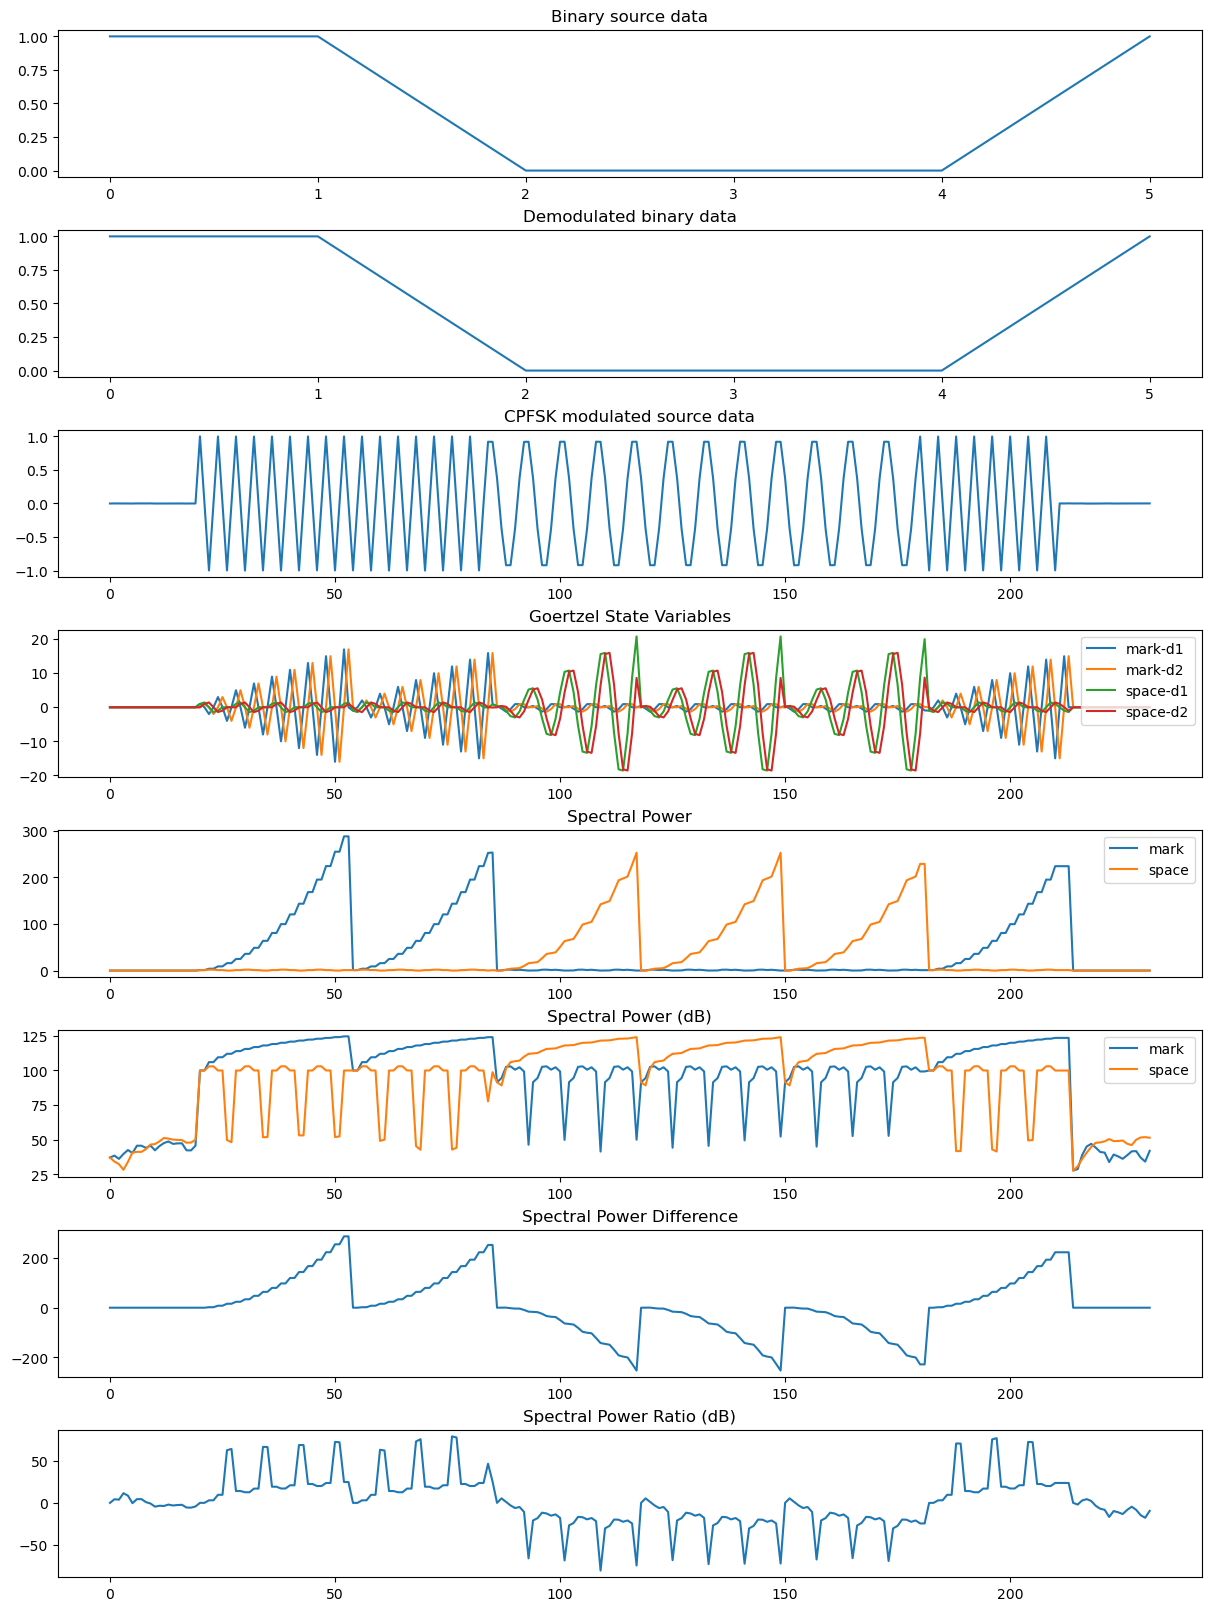

In [5]:
fig = plt.figure(figsize=(12, 16), dpi=100, layout='constrained')
axs = fig.subplot_mosaic([
    ['source'],
    ['output'],
    ['modulated'],
    ['state'],
    ['power'],
    ['power_db'],
    ['power_diff'],
    ['power_ratio'],
])
axs['source'].plot(source)
axs['source'].set_title('Binary source data')
axs['output'].plot(states[np.logical_not(np.isnan(states[:, 6])), 6])
axs['output'].set_title('Demodulated binary data')
axs['modulated'].plot(modulated)
axs['modulated'].set_title('CPFSK modulated source data')
axs['state'].plot(states[:, 0], label='mark-d1')
axs['state'].plot(states[:, 1], label='mark-d2')
axs['state'].plot(states[:, 3], label='space-d1')
axs['state'].plot(states[:, 4], label='space-d2')
axs['state'].legend()
axs['state'].set_title('Goertzel State Variables')
axs['power'].plot(states[:, 2], label='mark')
axs['power'].plot(states[:, 5], label='space')
axs['power'].legend()
axs['power'].set_title('Spectral Power')
axs['power_db'].plot(to_decibel(states[:, 2], 0), label='mark')
axs['power_db'].plot(to_decibel(states[:, 5], 0), label='space')
axs['power_db'].legend()
axs['power_db'].set_title('Spectral Power (dB)')
axs['power_diff'].plot(states[:, 2] - states[:, 5])
axs['power_diff'].set_title('Spectral Power Difference')
axs['power_ratio'].plot(to_decibel(states[:, 2], states[:, 5]))
axs['power_ratio'].set_title('Spectral Power Ratio (dB)')